## Deision Tree 

#### Deision Tree classifier

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [19]:
titanic = sns.load_dataset('titanic')

In [20]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [21]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [23]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [24]:
features = ['pclass', 'sex','fare','embarked','age']
target = ['survived']

In [25]:
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy='median')
titanic[['age']] = imp_median.fit_transform(titanic[['age']]) # this expects 2d ayyay/ df

imp_freq = SimpleImputer(strategy='most_frequent')
titanic[['embarked']] = imp_freq.fit_transform(titanic[['embarked']])

In [26]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

##### Encode

In [27]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked'] = le.fit_transform(titanic['embarked'])

In [31]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [32]:
X = titanic[features]
y = titanic[target]
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [33]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
X_train.head()

,pclass,sex,fare,embarked,age
445,1,1,81.8583,2,4.0
650,3,1,7.8958,2,28.0
172,3,0,11.1333,2,1.0
450,2,1,27.7500,2,36.0
314,2,1,26.2500,2,43.0


### Build Decision Tree Model

In [38]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train,y_train)

DecisionTreeClassifier()

In [39]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Accuracy= ",accuracy_score(y_test,y_pred))

Accuracy=  0.7574626865671642


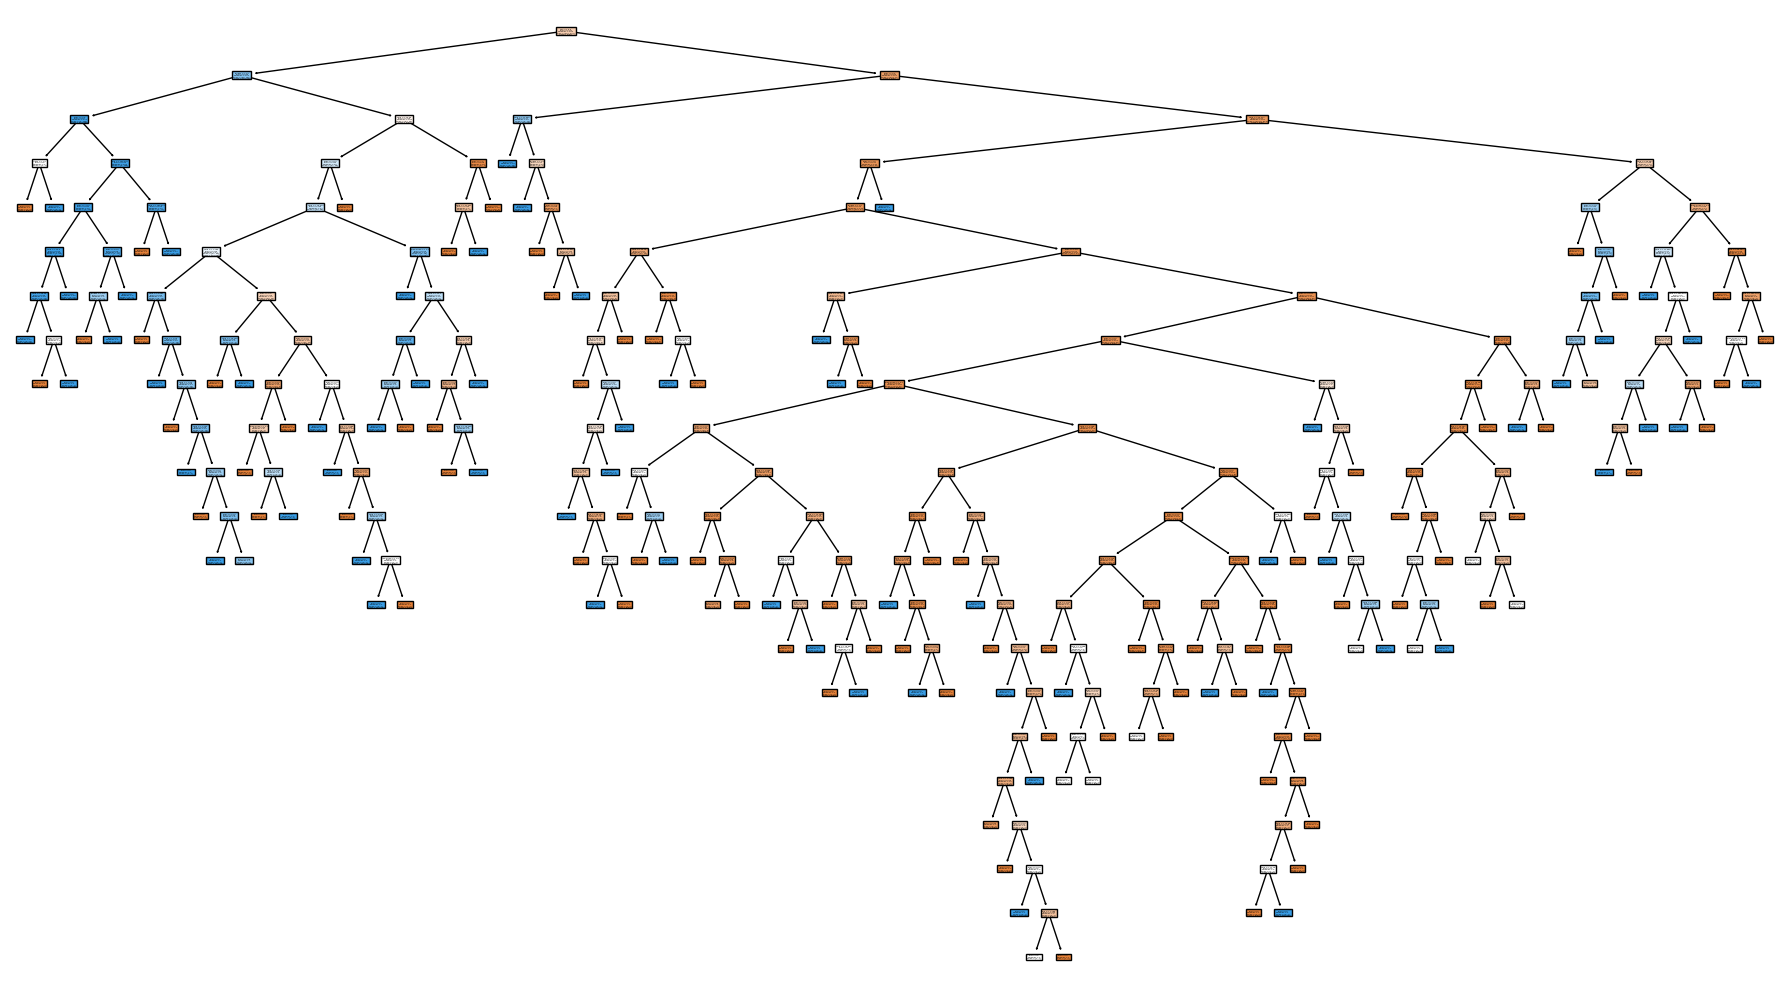

In [41]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

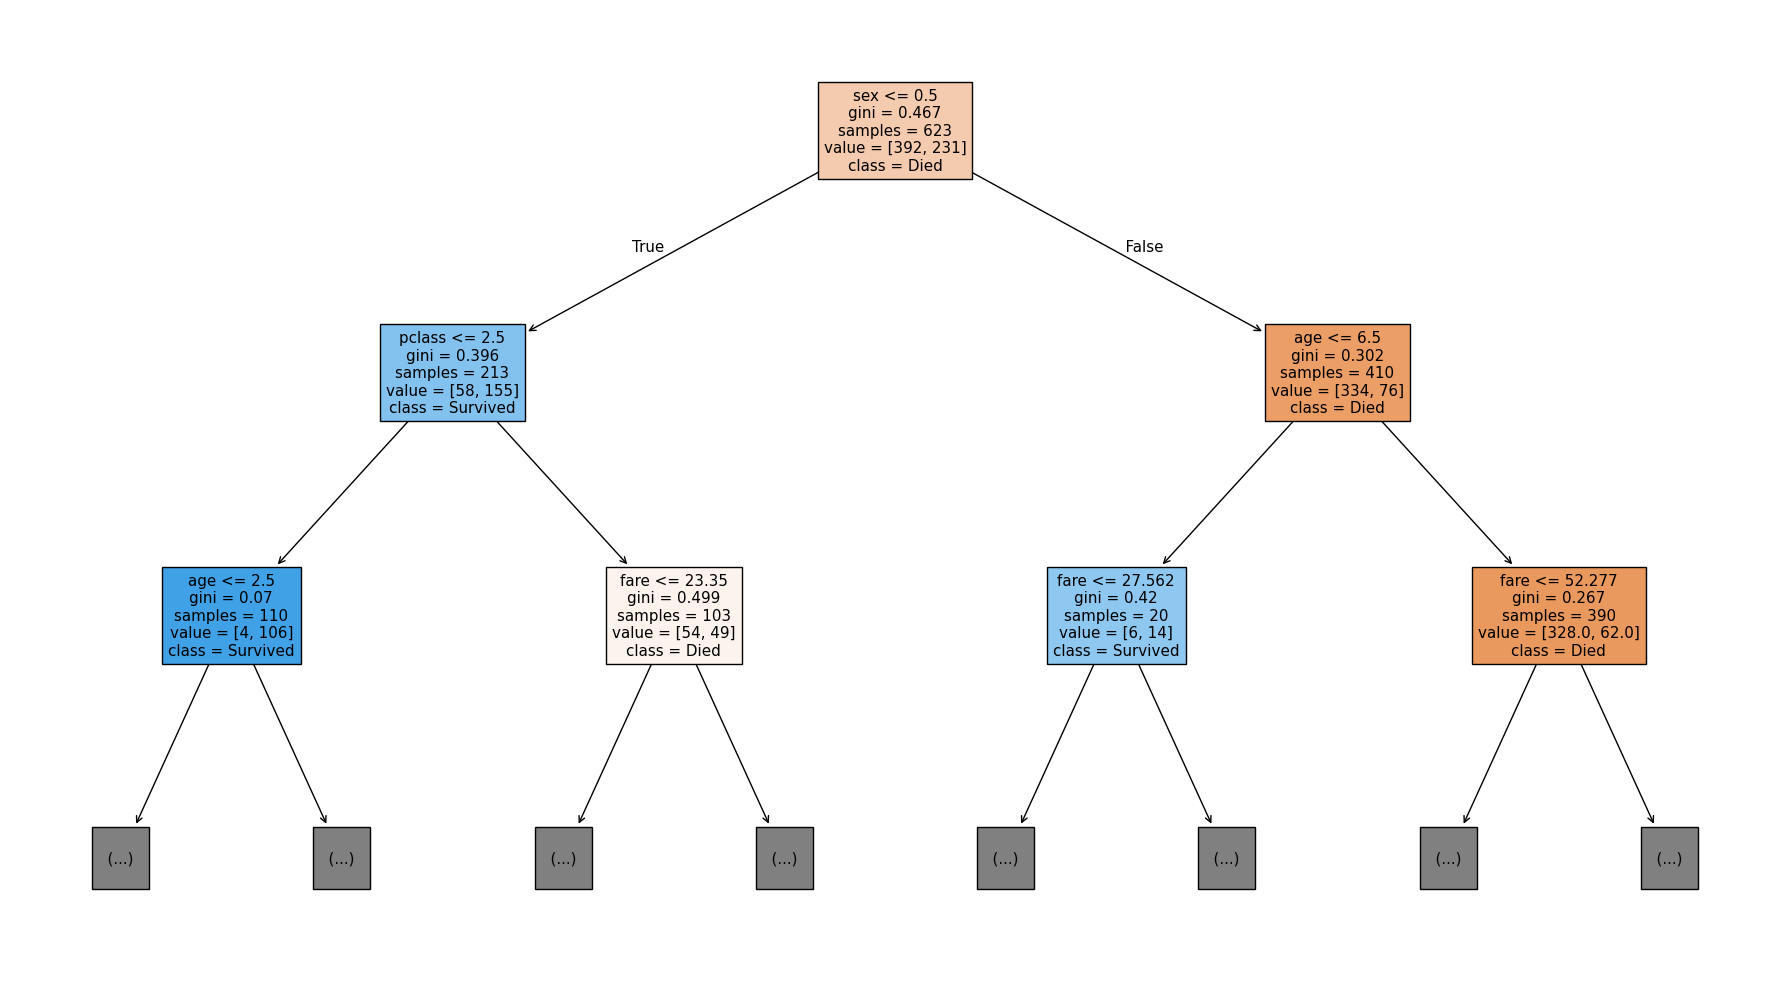

In [42]:
# to see clearly just top 2 nodes
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

#### Pre-Pruning Implementation

for depth 2 Accuracy: 0.7723880597014925
for depth 3 Accuracy: 0.8059701492537313


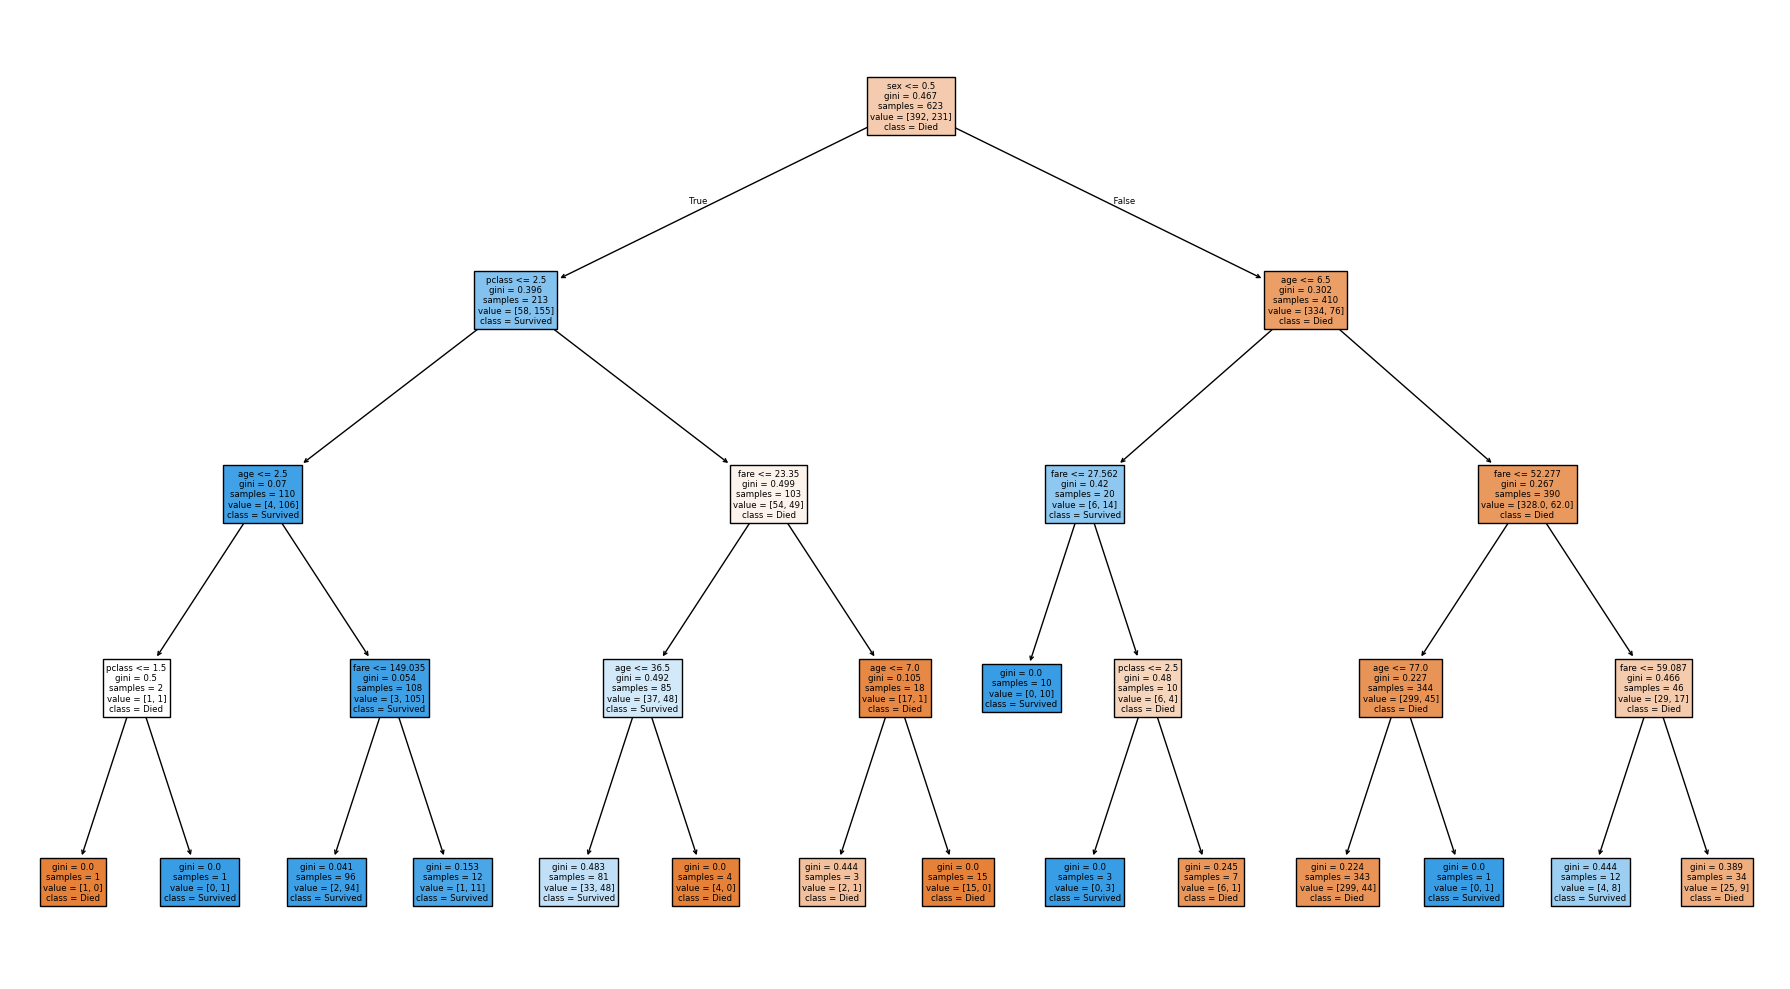

for depth 4 Accuracy: 0.8246268656716418
for depth 5 Accuracy: 0.7947761194029851
for depth 6 Accuracy: 0.7835820895522388
for depth 7 Accuracy: 0.7835820895522388
for depth 8 Accuracy: 0.8059701492537313


In [51]:
max_depth = [2,3,4,5,6,7,8]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    if depth==4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survived"],
            filled=True,
        )

        plt.tight_layout()
        plt.show()

    print(f"for depth {depth} Accuracy: {model.score(X_test, y_test)}") # bydef score is accuracy

- WE DECIDED TO GO WITH max_depth = 4

In [50]:
min_sample_split = [10,15,20,25,30]

for split in min_sample_split:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train,y_train)

    print(f"for sample split {split} Accuracy: {model.score(X_test, y_test)}")

for sample split 10 Accuracy: 0.8246268656716418
for sample split 15 Accuracy: 0.8171641791044776
for sample split 20 Accuracy: 0.8171641791044776
for sample split 25 Accuracy: 0.8208955223880597
for sample split 30 Accuracy: 0.8208955223880597


- 10 looks good split sample

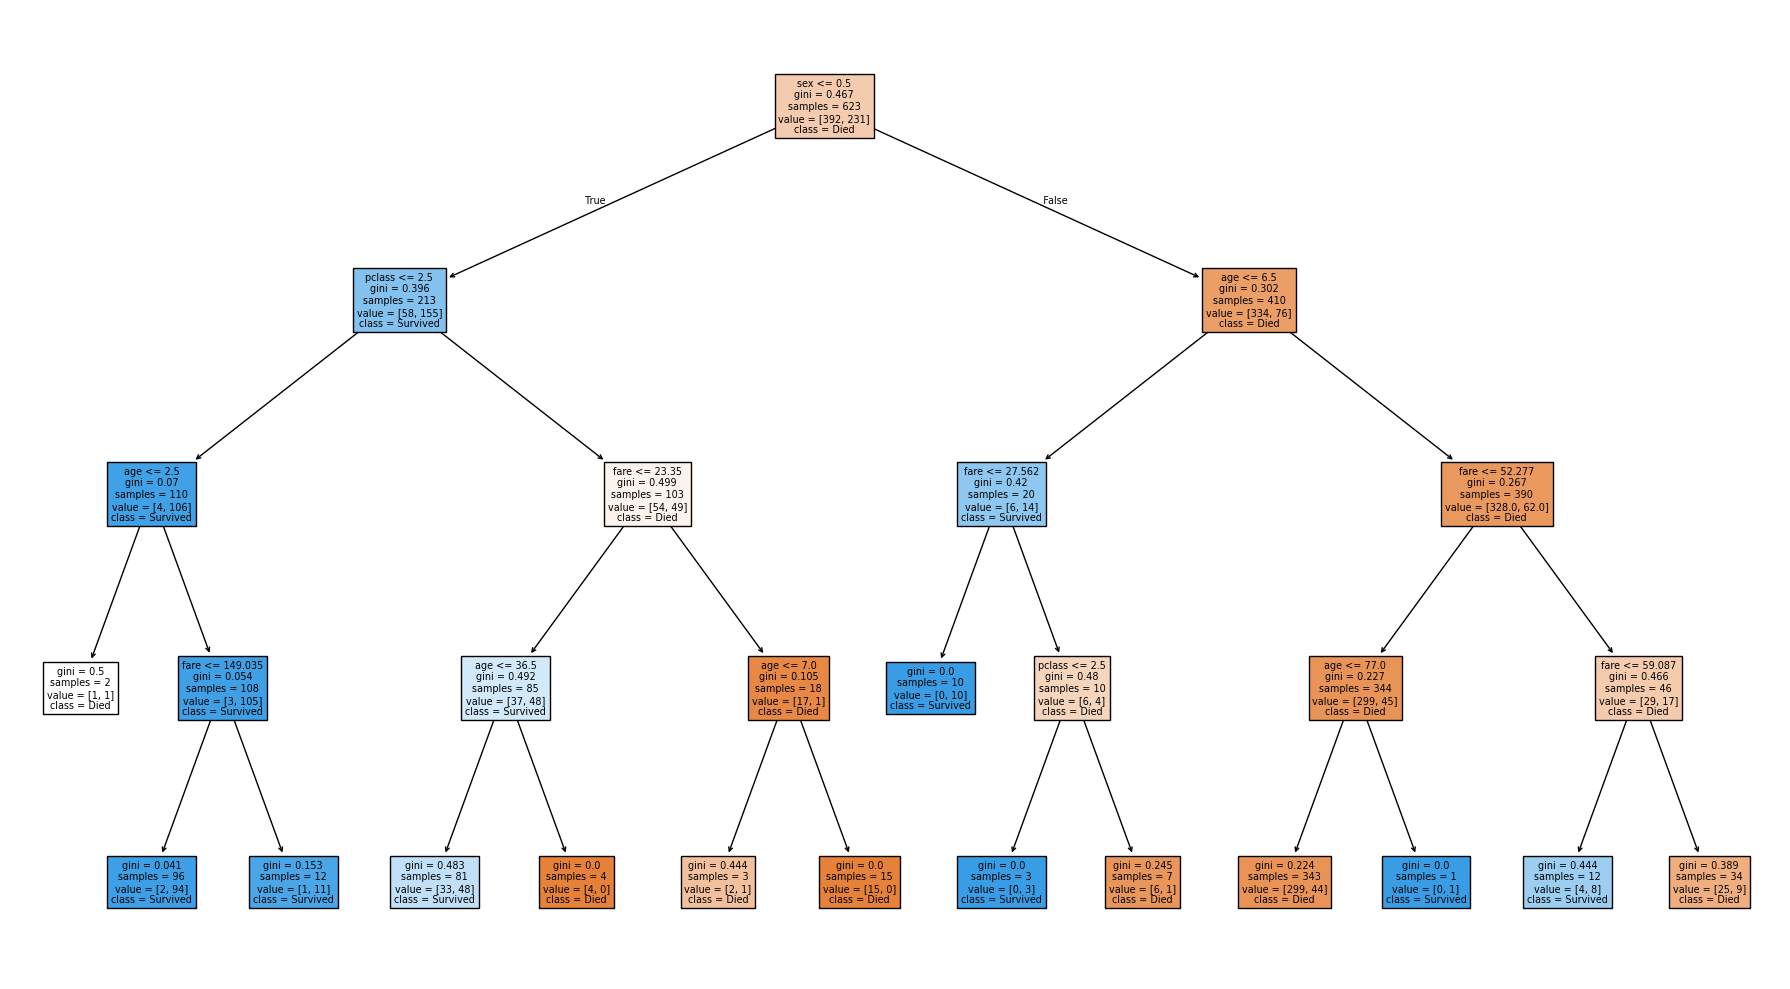

In [52]:
min_sample_split = [10,15,20,25,30]

for split in min_sample_split:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train,y_train)

    if split == 10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survived"],
            filled=True,
        )

        plt.tight_layout()
        plt.show()
        

#### Post-Pruning Implementation

In [53]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)



DecisionTreeClassifier(random_state=42)

In [55]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [60]:
# train our model for alphas

trees = []


for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train,y_train)

    tree.append((model, alpha))
        

In [61]:
best_acc = 0
best_alpha = 0

for model,alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha



In [62]:
print(best_acc,best_alpha)

0.8208955223880597 0.0017121455323702516


In [68]:
best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_model.fit(X_train , y_train)
print("accuracy_score = ",best_model.score(X_test, y_test))


accuracy_score =  0.8208955223880597


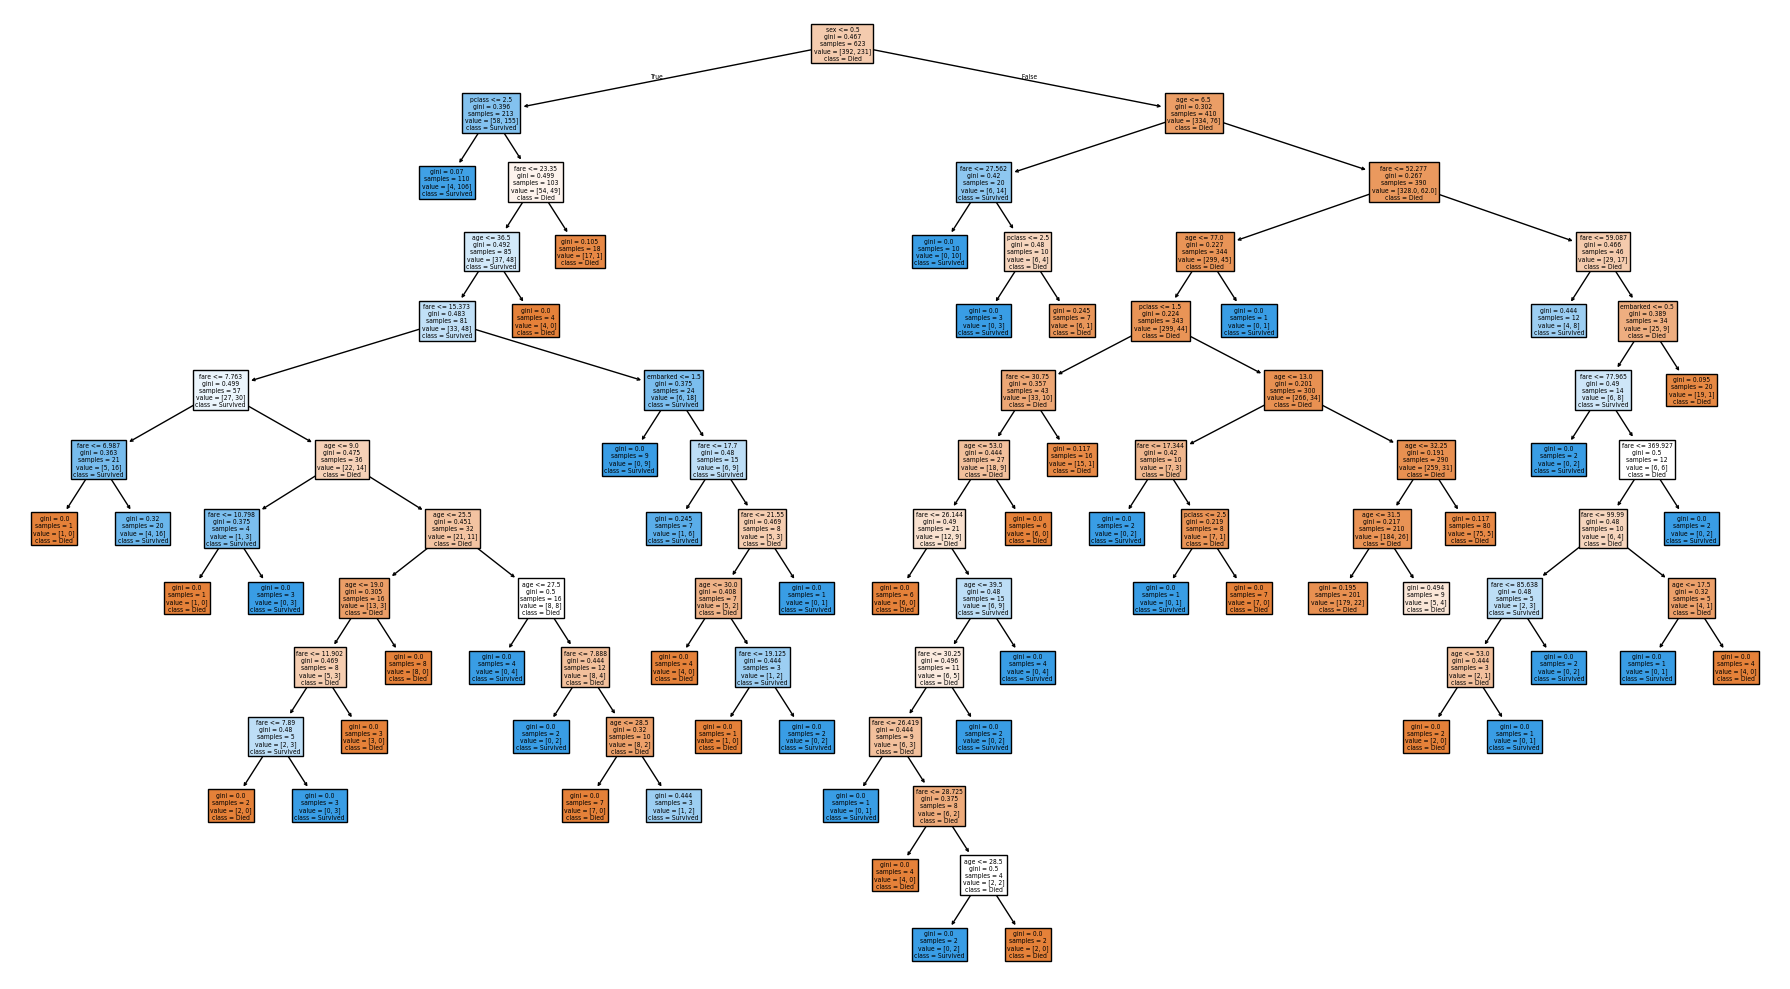

In [70]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=features,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

accuracy_score =  0.8246268656716418


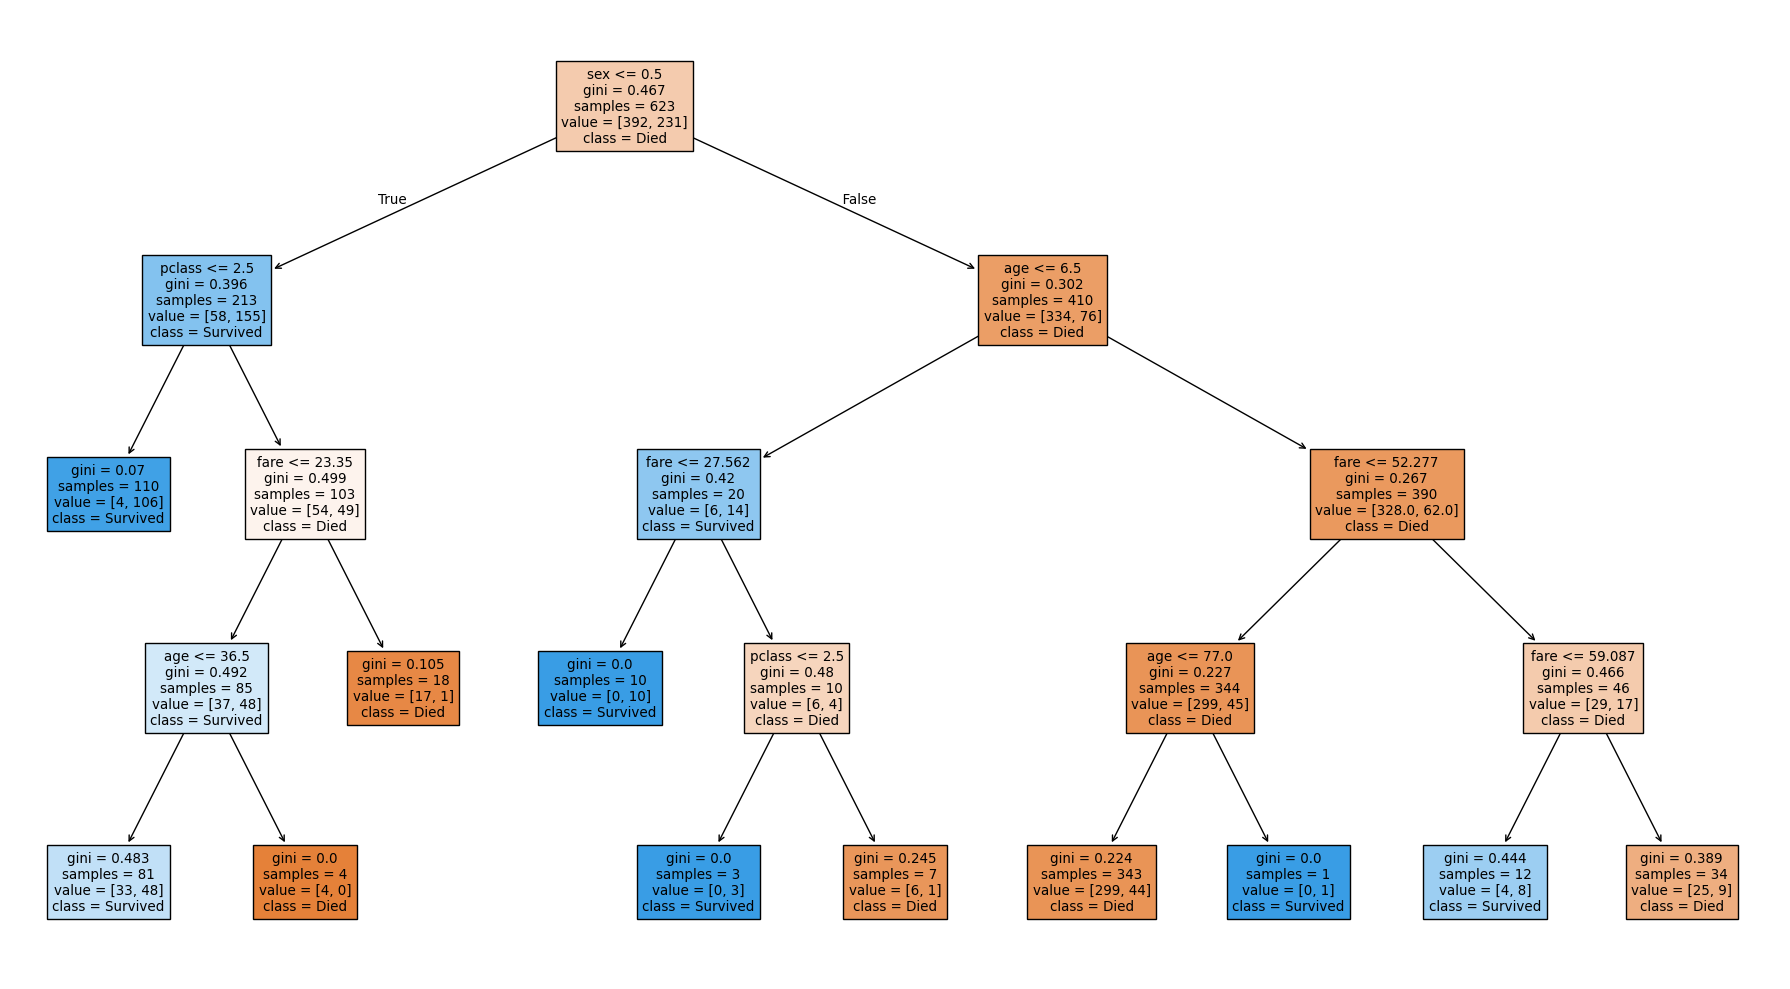

In [72]:
best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha,max_depth=4) # pre and post pruning
best_model.fit(X_train , y_train)
print("accuracy_score = ",best_model.score(X_test, y_test))

plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=features,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()